# Customer Churn Risk Modeling

**Author:** Raya Sergieva  
**Course:** Data Science Final Exam, 2026  
**Date:** May 2026

---

## Project Overview

This notebook develops a customer churn risk model using two independent datasets — a US telecommunications dataset (IBM Telco) and a European retail banking dataset (Churn Modelling). The goal is to predict the probability that a current customer will churn within a defined future window, evaluate that prediction rigorously, and analyze what features drive churn risk.

## Why churn matters

For subscription-based and account-based businesses, retaining an existing customer is typically 5–10 times cheaper than acquiring a new one. If churn risk can be predicted accurately and *calibrated* — meaning the predicted probabilities reflect real-world frequencies — a company can target retention offers cost-effectively. This makes churn modeling one of the most consistently valuable applications of supervised machine learning in industry.

## Approach

1. Load and validate both datasets independently.
2. Perform exploratory data analysis on each.
3. Clean, harmonize feature semantics where possible, and merge into a single analysis-ready dataset.
4. Define the prediction problem mathematically and discuss the choice of loss function and evaluation metrics.
5. Train and compare three model families: logistic regression (interpretable baseline), random forest (non-linear baseline), and gradient boosting (strong non-linear model).
6. Evaluate using ROC-AUC, PR-AUC, Brier score, and calibration plots — accuracy alone is misleading under class imbalance.
7. Interpret the best model using SHAP values to identify churn drivers.
8. Discuss limitations, generalization across domains, and possible extensions.

In [1]:
# Core data science libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings — readable output in the notebook
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

# Reproducibility — fix the random seed everywhere we can
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Confirm versions for transparency
print(f"pandas:     {pd.__version__}")
print(f"numpy:      {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"seaborn:    {sns.__version__}")

pandas:     3.0.3
numpy:      2.4.4
matplotlib: 3.10.9
seaborn:    0.13.2


In [2]:
# Paths are relative to the notebook's location (notebooks/)
# so ../data/raw points back up to the project root, then into data/raw
RAW_DATA_DIR = "../data/raw"

# Load both raw datasets
telco = pd.read_csv(f"{RAW_DATA_DIR}/telco_churn.csv")
bank = pd.read_csv(f"{RAW_DATA_DIR}/bank_churn.csv")

# Report shapes so we can verify we got what we expected
print(f"Telco churn dataset:  {telco.shape[0]:>6,} rows × {telco.shape[1]:>2} columns")
print(f"Bank churn dataset:   {bank.shape[0]:>6,} rows × {bank.shape[1]:>2} columns")

Telco churn dataset:   7,043 rows × 21 columns
Bank churn dataset:   10,000 rows × 14 columns


## 1. First look at the raw data

Before any cleaning or modeling, we inspect each dataset independently to understand its structure, column types, missing values, and target distribution. This step catches encoding issues, unexpected dtypes, and obvious data quality problems before they propagate into later analysis.

### 1.1 Telco dataset — preview

In [3]:
# First 5 rows of the Telco dataset
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Column types and non-null counts
telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Pandas' view of missing values per column (Telco)
# Sort by missing count descending, show top 10
telco.isna().sum().sort_values(ascending=False).head(10)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

In [6]:
# Investigate TotalCharges specifically
# It's typed as a string — that suggests something non-numeric is hiding in it
# Try converting to numeric and see how many fail to parse
total_charges_numeric = pd.to_numeric(telco["TotalCharges"], errors="coerce")

n_unparseable = total_charges_numeric.isna().sum()
print(f"Rows where TotalCharges fails to parse as a number: {n_unparseable}")
print()

# Show those problematic rows
print("The rows with the unparseable TotalCharges:")
telco.loc[total_charges_numeric.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Rows where TotalCharges fails to parse as a number: 11

The rows with the unparseable TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### 1.2 Data quality finding: `TotalCharges` column

Investigation reveals that `TotalCharges` is stored as a string rather than numeric. The cause: 11 rows (0.16% of the data) contain whitespace instead of a number. All 11 are customers with `tenure = 0` — i.e. brand-new customers who have not yet been billed — and all 11 are non-churners (which is mechanically consistent: a customer with 0 months of tenure cannot have churned).

This is **structurally absent data**, not missing data in the usual sense. We will impute `TotalCharges = 0` for these rows during cleaning, which is the natural interpretation: a customer who has been billed zero times has a total charge of zero.

In [7]:
# Target distribution (Telco)
print("Churn distribution (Telco):")
print(telco["Churn"].value_counts())
print()
print("Churn rate:")
print(telco["Churn"].value_counts(normalize=True).round(3))

Churn distribution (Telco):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


## 2. Bank dataset inspection

We now perform the same structural inspection on the bank churn dataset — schema, dtypes, missing values, and target distribution. Doing this independently for each source (before any merging or harmonization) is important: it lets us catch source-specific issues without the confusion of mixed-origin rows.

### 2.1 Bank dataset — preview

In [8]:
# First 5 rows of the Bank dataset
bank.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# Column types and non-null counts
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [10]:
# Missing values per column (Bank)
bank.isna().sum().sort_values(ascending=False).head(10)

RowNumber        0
CustomerId       0
Surname          0
CreditScore      0
Geography        0
Gender           0
Age              0
Tenure           0
Balance          0
NumOfProducts    0
dtype: int64

In [11]:
# Target distribution (Bank)
print("Exited distribution (Bank):")
print(bank["Exited"].value_counts())
print()
print("Exit rate:")
print(bank["Exited"].value_counts(normalize=True).round(3))

Exited distribution (Bank):
Exited
0    7963
1    2037
Name: count, dtype: int64

Exit rate:
Exited
0    0.796
1    0.204
Name: proportion, dtype: float64


### 2.2 Bank dataset — summary of findings

The bank dataset is structurally cleaner than the Telco one:
- No type coercion problems — all numeric columns are stored as numerics.
- No hidden missing values — the `isna()` check returns zero across all columns.
- Three columns are identifiers with no predictive value (`RowNumber`, `CustomerId`, `Surname`) and will be dropped during cleaning.

The target column is `Exited` (1/0) rather than `Churn` (Yes/No). We will harmonize naming during cleaning.

### 2.3 Cross-dataset summary before cleaning

| Aspect              | Telco                          | Bank                                   |
|---------------------|--------------------------------|----------------------------------------|
| Rows                | 7,043                          | 10,000                                 |
| Columns             | 21                             | 14                                     |
| Domain              | US telecommunications          | European retail banking                |
| Target column       | `Churn` (Yes/No)               | `Exited` (1/0)                         |
| Positive class rate | 26.5%                          | 20.4%                                  |
| Data quality issues | `TotalCharges` mis-typed (11 rows); placeholder "No service" values | None observed |

Both datasets exhibit moderate class imbalance, so accuracy alone will be misleading as an evaluation metric. We will use ROC-AUC, PR-AUC, and calibration metrics throughout. The different positive-class rates between domains also raise an interesting question for later: do features and modeling approaches that work well on one domain generalize to the other?

---

## 3. Data cleaning

Based on the inspection in sections 1 and 2, we now apply the cleaning steps required to make each dataset analysis-ready and to harmonize their schemas where it makes sense.

The cleaning logic itself lives in `src/cleaning.py` rather than inline in the notebook. This separation keeps the notebook narrative readable, makes the cleaning functions reusable and testable, and follows the standard layout for Python data-science projects. The two functions are:

- `clean_telco(df)` — handles the `TotalCharges` mistyping, drops the identifier, collapses redundant placeholder values (`"No internet service"`, `"No phone service"`), normalizes the `SeniorCitizen` encoding, and converts the target to a 1/0 column named `churn`.
- `clean_bank(df)` — drops the three identifier/bookkeeping columns and renames `Exited` to `churn` for consistency.

After cleaning, both datasets share a common target column name (`churn`) with a common encoding (1 = churned, 0 = retained).

In [12]:
# Make src/ importable from the notebook (which lives in notebooks/)
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # we are in notebooks/, parent is the project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean_telco, clean_bank

# Apply the cleaners
telco_clean = clean_telco(telco)
bank_clean = clean_bank(bank)

print(f"Telco — raw: {telco.shape}, cleaned: {telco_clean.shape}")
print(f"Bank  — raw: {bank.shape}, cleaned: {bank_clean.shape}")

Telco — raw: (7043, 21), cleaned: (7043, 20)
Bank  — raw: (10000, 14), cleaned: (10000, 11)


In [13]:
# Verify Telco cleaning
print("Telco cleaned — dtypes (first few columns):")
print(telco_clean.dtypes.head(10))
print()

print("TotalCharges — is it numeric now?")
print(f"  dtype: {telco_clean['TotalCharges'].dtype}")
print(f"  min:   {telco_clean['TotalCharges'].min():.2f}")
print(f"  max:   {telco_clean['TotalCharges'].max():.2f}")
print(f"  rows where TotalCharges == 0: {(telco_clean['TotalCharges'] == 0).sum()}")
print()

print("churn target distribution:")
print(telco_clean["churn"].value_counts())
print()

print("Sample of cleaned MultipleLines values (should be Yes/No only, no placeholders):")
print(telco_clean["MultipleLines"].value_counts())

Telco cleaned — dtypes (first few columns):
gender               str
SeniorCitizen        str
Partner              str
Dependents           str
tenure             int64
PhoneService         str
MultipleLines        str
InternetService      str
OnlineSecurity       str
OnlineBackup         str
dtype: object

TotalCharges — is it numeric now?
  dtype: float64
  min:   0.00
  max:   8684.80
  rows where TotalCharges == 0: 11

churn target distribution:
churn
0    5174
1    1869
Name: count, dtype: int64

Sample of cleaned MultipleLines values (should be Yes/No only, no placeholders):
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64


In [14]:
# Verify Bank cleaning
print("Bank cleaned — columns:")
print(list(bank_clean.columns))
print()

print("churn target distribution:")
print(bank_clean["churn"].value_counts())
print()

print("Confirming dropped columns are gone:")
for col in ["RowNumber", "CustomerId", "Surname", "Exited"]:
    assert col not in bank_clean.columns, f"{col} should have been dropped!"
print("  All dropped columns are gone ✓")

Bank cleaned — columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'churn']

churn target distribution:
churn
0    7963
1    2037
Name: count, dtype: int64

Confirming dropped columns are gone:
  All dropped columns are gone ✓


### 3.1 Persisting the cleaned datasets

We save the cleaned datasets to `data/processed/` for downstream use. These files are excluded from version control (see `.gitignore`) — they are deterministic outputs of the cleaning functions in `src/cleaning.py` and can be reconstructed at any time by re-running this notebook. Storing them on disk simply avoids recomputation.

In [15]:
# Save cleaned datasets to data/processed/
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

telco_path = PROCESSED_DIR / "telco_clean.csv"
bank_path = PROCESSED_DIR / "bank_clean.csv"

telco_clean.to_csv(telco_path, index=False)
bank_clean.to_csv(bank_path, index=False)

print(f"Saved: {telco_path.relative_to(PROJECT_ROOT)}  ({telco_path.stat().st_size / 1024:.1f} KB)")
print(f"Saved: {bank_path.relative_to(PROJECT_ROOT)}  ({bank_path.stat().st_size / 1024:.1f} KB)")

Saved: data\processed\telco_clean.csv  (718.3 KB)
Saved: data\processed\bank_clean.csv  (468.0 KB)


---

## 4. Exploratory Data Analysis

We now examine each cleaned dataset to understand the structure of churn — who churns, when, and how that relates to the available features. The analysis here is question-driven rather than exhaustive: each plot or table addresses a specific question that informs later modeling and interpretation, rather than mechanically visualizing every column.

The questions we examine in each dataset are:

1. **Demographic and behavioral patterns** — Are there subgroups with markedly different churn rates?
2. **Tenure dynamics** — How does churn risk evolve over the customer lifetime?
3. **Price sensitivity** — Are higher-paying customers more or less likely to leave?
4. **Feature relationships** — Are there correlations or redundancies among numeric features that will influence modeling choices?

We then close the section with a brief cross-dataset summary highlighting where the two domains agree and where they differ.

### 4.1 Telco — churn rate by contract type

The most consistently observed pattern in subscription business analytics is that contract length is a dominant driver of churn — month-to-month subscribers churn far more than those locked into one- or two-year contracts. We confirm this is the case here.

Churn rate by contract type:
                churn_rate  n_customers
Contract                               
Month-to-month       0.427         3875
One year             0.113         1473
Two year             0.028         1695



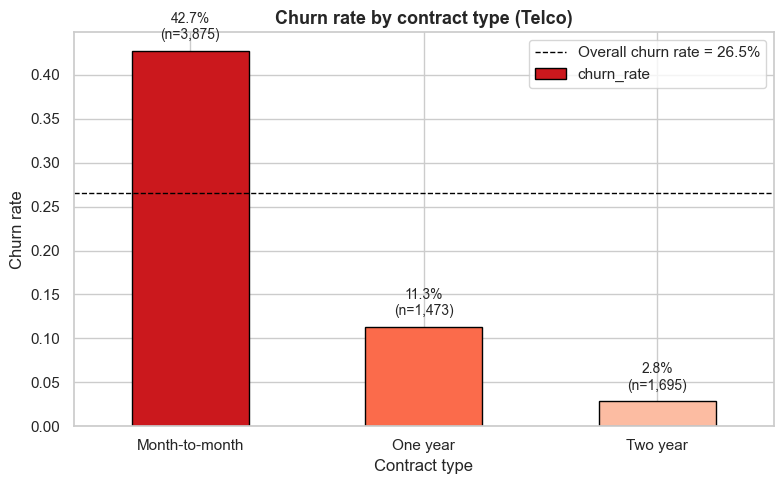

In [16]:
# Churn rate by contract type
contract_churn = (
    telco_clean.groupby("Contract")["churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n_customers"})
    .sort_values("churn_rate", ascending=False)
)

print("Churn rate by contract type:")
print(contract_churn.round(3))
print()

fig, ax = plt.subplots(figsize=(8, 5))
contract_churn["churn_rate"].plot(
    kind="bar", ax=ax, color=sns.color_palette("Reds_r", n_colors=3), edgecolor="black"
)
ax.axhline(
    telco_clean["churn"].mean(),
    color="black", linestyle="--", linewidth=1,
    label=f"Overall churn rate = {telco_clean['churn'].mean():.1%}",
)
ax.set_title("Churn rate by contract type (Telco)", fontsize=13, fontweight="bold")
ax.set_xlabel("Contract type")
ax.set_ylabel("Churn rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()

# Annotate each bar with the rate and count
for i, (rate, n) in enumerate(zip(contract_churn["churn_rate"], contract_churn["n_customers"])):
    ax.text(i, rate + 0.01, f"{rate:.1%}\n(n={n:,})", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

**Finding.** Contract length is the dominant driver of churn in the Telco dataset. Month-to-month customers churn at 42.7%, more than 15× the rate of two-year customers (2.8%). This makes intuitive business sense: a customer who has committed to a long contract has a high switching cost and a lower outside option. From a modeling perspective, `Contract` will be one of the most informative features, and any model that fails to capture this pattern is fundamentally broken.

### 4.2 Telco — churn dynamics over tenure

Tenure (months as a customer) is universally one of the strongest churn signals: most attrition happens in the first few months of a customer relationship, and customers who survive that early period tend to stay much longer. We bucket tenure into one-year ranges and examine the churn rate in each.

Churn rate by tenure bucket:
               churn_rate  n_customers
tenure_bucket                         
0-6m                0.529         1481
7-12m               0.359          705
13-24m              0.287         1024
25-36m              0.216          832
37-48m              0.190          762
49-60m              0.144          832
61-72m              0.066         1407



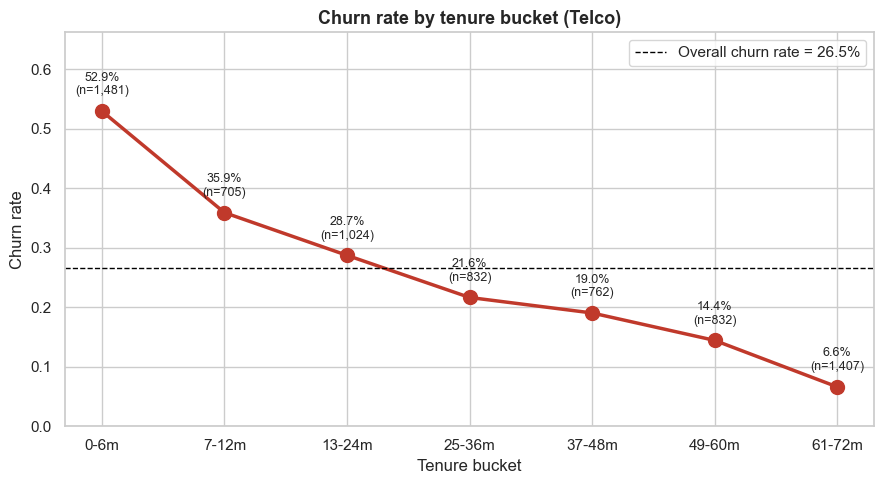

In [17]:
# Bucket tenure into one-year ranges and compute churn rate per bucket
tenure_bins = [0, 6, 12, 24, 36, 48, 60, 72]
tenure_labels = ["0-6m", "7-12m", "13-24m", "25-36m", "37-48m", "49-60m", "61-72m"]

telco_clean["tenure_bucket"] = pd.cut(
    telco_clean["tenure"], bins=tenure_bins, labels=tenure_labels, include_lowest=True
)

tenure_churn = (
    telco_clean.groupby("tenure_bucket", observed=True)["churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n_customers"})
)

print("Churn rate by tenure bucket:")
print(tenure_churn.round(3))
print()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    tenure_churn.index.astype(str), tenure_churn["churn_rate"],
    marker="o", markersize=10, linewidth=2.5, color="#c0392b"
)
ax.axhline(
    telco_clean["churn"].mean(),
    color="black", linestyle="--", linewidth=1,
    label=f"Overall churn rate = {telco_clean['churn'].mean():.1%}",
)
ax.set_title("Churn rate by tenure bucket (Telco)", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure bucket")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, max(tenure_churn["churn_rate"]) * 1.25)

# Annotate each point
for i, (rate, n) in enumerate(zip(tenure_churn["churn_rate"], tenure_churn["n_customers"])):
    ax.annotate(
        f"{rate:.1%}\n(n={n:,})",
        xy=(i, rate), xytext=(0, 12),
        textcoords="offset points", ha="center", fontsize=9,
    )

ax.legend()
plt.tight_layout()
plt.show()

# Remove the bucket column so we don't pollute the cleaned DataFrame for later
telco_clean = telco_clean.drop(columns=["tenure_bucket"])

**Finding.** Churn risk decays sharply with tenure. More than half of customers who have been with the company for under 6 months churn (52.9%), versus just 6.6% of customers in their 6th year. The decay is monotonic but not strictly exponential — it plateaus between months 25-48 before falling again, possibly reflecting renewal-cycle effects.

The takeaway for modeling: tenure will be one of the strongest individual predictors, but its relationship with churn is non-linear. Linear models will need either bucketing or a non-linear transformation; tree-based models will capture this pattern naturally.

### 4.3 Telco — price sensitivity

Whether high-paying customers are more or less likely to churn is not obvious in advance. Two opposing intuitions exist: high-paying customers may churn more because they have more to save by leaving, *or* less because they are typically heavier service users with more switching friction. We examine the relationship between monthly charges and churn directly.

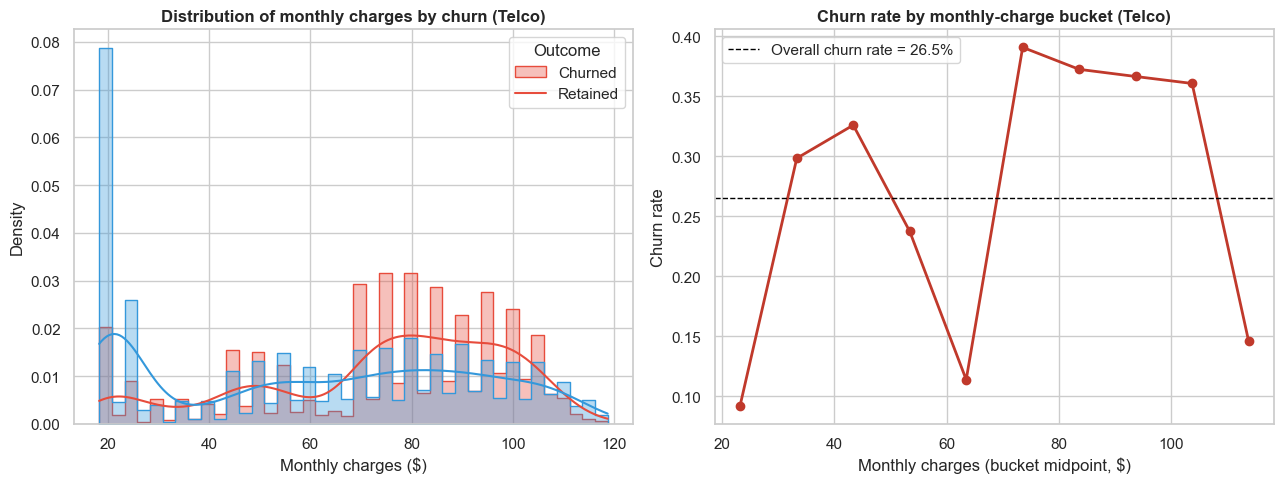

Mean MonthlyCharges by churn status:
        mean  median    std
churn                      
0      61.27   64.43  31.09
1      74.44   79.65  24.67


In [18]:
# Distribution of MonthlyCharges, split by churn status
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overlapping histograms
sns.histplot(
    data=telco_clean, x="MonthlyCharges", hue="churn",
    bins=40, kde=True, palette={0: "#3498db", 1: "#e74c3c"},
    ax=axes[0], stat="density", common_norm=False, element="step", alpha=0.35,
)
axes[0].set_title("Distribution of monthly charges by churn (Telco)", fontweight="bold")
axes[0].set_xlabel("Monthly charges ($)")
axes[0].set_ylabel("Density")
axes[0].legend(["Churned", "Retained"], title="Outcome")

# Right: churn rate by monthly-charge bucket
charge_bins = pd.cut(telco_clean["MonthlyCharges"], bins=10)
charge_churn = telco_clean.groupby(charge_bins, observed=True)["churn"].agg(["mean", "count"])

bin_midpoints = [interval.mid for interval in charge_churn.index]
axes[1].plot(bin_midpoints, charge_churn["mean"], marker="o", color="#c0392b", linewidth=2)
axes[1].axhline(
    telco_clean["churn"].mean(),
    color="black", linestyle="--", linewidth=1,
    label=f"Overall churn rate = {telco_clean['churn'].mean():.1%}",
)
axes[1].set_title("Churn rate by monthly-charge bucket (Telco)", fontweight="bold")
axes[1].set_xlabel("Monthly charges (bucket midpoint, $)")
axes[1].set_ylabel("Churn rate")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Mean MonthlyCharges by churn status:")
print(telco_clean.groupby("churn")["MonthlyCharges"].agg(["mean", "median", "std"]).round(2))

**Finding.** The relationship between price and churn is *non-monotonic*. Customers paying the very lowest charges (~$20/month, predominantly phone-only plans) churn rarely (~10%). Churn rises steeply through the $40-60 range, drops to a local minimum around $60 (likely the basic-internet-plus-phone cohort), then spikes again to ~38% in the $70-90 band — which corresponds approximately to fiber-optic internet plans. The highest-paying customers (>$100, with multiple services bundled) churn at lower rates again.

This shape strongly suggests that **the underlying driver is service type, not price itself**: certain service offerings (most plausibly fiber internet) have intrinsic churn problems, and they happen to fall in a particular price range. Pure linear models will struggle to capture this — they would push toward a "price → churn" coefficient that's a poor summary of the true structure. Tree-based models and SHAP analysis (Section 7) will let us separate the price effect from the service-mix effect properly.

### 4.4 Telco — numeric feature correlations

Before moving on, we examine the correlation structure among the three numeric features (`tenure`, `MonthlyCharges`, `TotalCharges`) and the binary target. This helps anticipate multicollinearity issues for linear models — `TotalCharges` is mechanically `tenure × MonthlyCharges` plus noise, so we expect very high correlation.

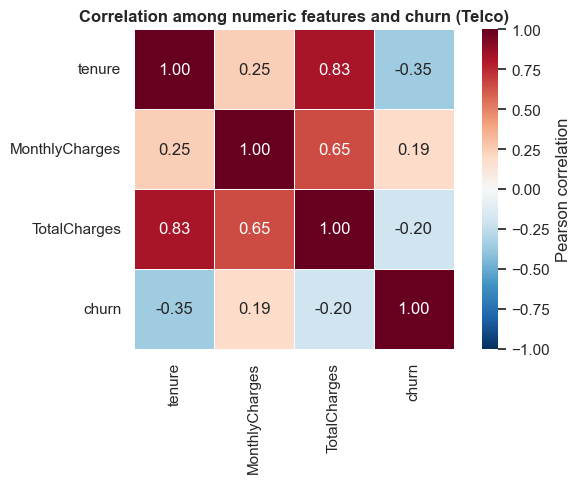

Pairwise correlations:
                tenure  MonthlyCharges  TotalCharges  churn
tenure           1.000           0.248         0.826 -0.352
MonthlyCharges   0.248           1.000         0.651  0.193
TotalCharges     0.826           0.651         1.000 -0.198
churn           -0.352           0.193        -0.198  1.000


In [19]:
# Correlation among numeric features and target
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "churn"]
corr = telco_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}, ax=ax,
)
ax.set_title("Correlation among numeric features and churn (Telco)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Pairwise correlations:")
print(corr.round(3))

**Finding.** Three observations from the correlation matrix:

1. **`tenure` ↔ `TotalCharges` correlation is 0.83.** This is severe multicollinearity, but it has a mechanical explanation: total charges accumulate over tenure at roughly the monthly rate, so `TotalCharges ≈ tenure × MonthlyCharges + noise`. Including both features in a linear model would inflate coefficient variance without adding meaningful information.
2. **`tenure` has the strongest individual correlation with churn (-0.35)** among the numeric features, consistent with the dynamics observed in Section 4.2.
3. **`MonthlyCharges` has only modest correlation with churn (+0.19)** — consistent with the non-monotonic relationship found in Section 4.3, where Pearson correlation cannot fully capture the underlying structure.

**Modeling decision.** For the linear baseline, we will drop `TotalCharges` and retain `tenure` + `MonthlyCharges`. Tree-based models, which are not affected by multicollinearity in the same way, can use all three columns without harm.

### 4.5 Telco summary

The Telco dataset reveals a clear, intuitive churn structure: short tenure, month-to-month contracts, and specific service offerings (probably fiber internet, to be confirmed in Section 7) drive most of the risk. The non-monotonic price relationship suggests that any high-quality model will need to handle non-linearity — pointing toward gradient boosting as a likely winner.

We now move to the bank dataset and ask the same questions to see whether these patterns generalize across domains.

### 4.6 Bank — churn rate by geography

The bank dataset has no explicit contract-length feature, but it has `Geography` (France, Spain, Germany). Geographic location often proxies for product offerings, customer demographics, and market conditions, and is worth examining as a first cut.

Churn rate by geography:
           churn_rate  n_customers
Geography                         
Germany         0.324         2509
Spain           0.167         2477
France          0.162         5014



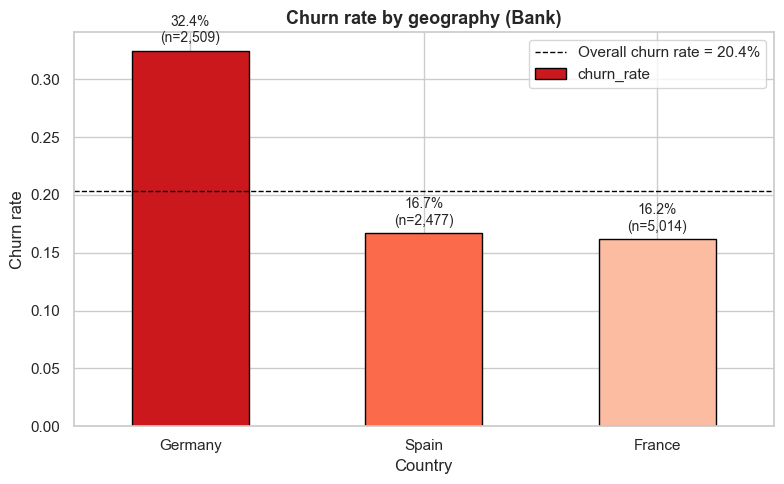

In [20]:
# Churn rate by geography (Bank)
geo_churn = (
    bank_clean.groupby("Geography")["churn"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n_customers"})
    .sort_values("churn_rate", ascending=False)
)

print("Churn rate by geography:")
print(geo_churn.round(3))
print()

fig, ax = plt.subplots(figsize=(8, 5))
geo_churn["churn_rate"].plot(
    kind="bar", ax=ax, color=sns.color_palette("Reds_r", n_colors=3), edgecolor="black"
)
ax.axhline(
    bank_clean["churn"].mean(),
    color="black", linestyle="--", linewidth=1,
    label=f"Overall churn rate = {bank_clean['churn'].mean():.1%}",
)
ax.set_title("Churn rate by geography (Bank)", fontsize=13, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Churn rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()

for i, (rate, n) in enumerate(zip(geo_churn["churn_rate"], geo_churn["n_customers"])):
    ax.text(i, rate + 0.005, f"{rate:.1%}\n(n={n:,})", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

**Finding.** Germany has substantially higher churn (32.4%) than France (16.2%) or Spain (16.7%) — roughly double the rate of the other two countries. France and Spain are nearly indistinguishable in churn rate despite very different customer counts (5,014 vs 2,477).

This is a strong signal but also a coarse one: it points to *something different about the German market* — product, competition, demographics, or service quality — that this dataset alone cannot disambiguate. From a modeling perspective, the practical implication is that the three-level `Geography` feature could be collapsed to a binary "Germany / non-Germany" indicator with minimal loss of information. We retain the three-level encoding for now and let the models discover this pattern themselves.

### 4.7 Bank — age and churn

In the bank dataset, demographic features are richer than in the Telco data. Age is the most natural starting point: older customers may have different banking needs, more accumulated wealth, and different relationships with the institution than younger ones.

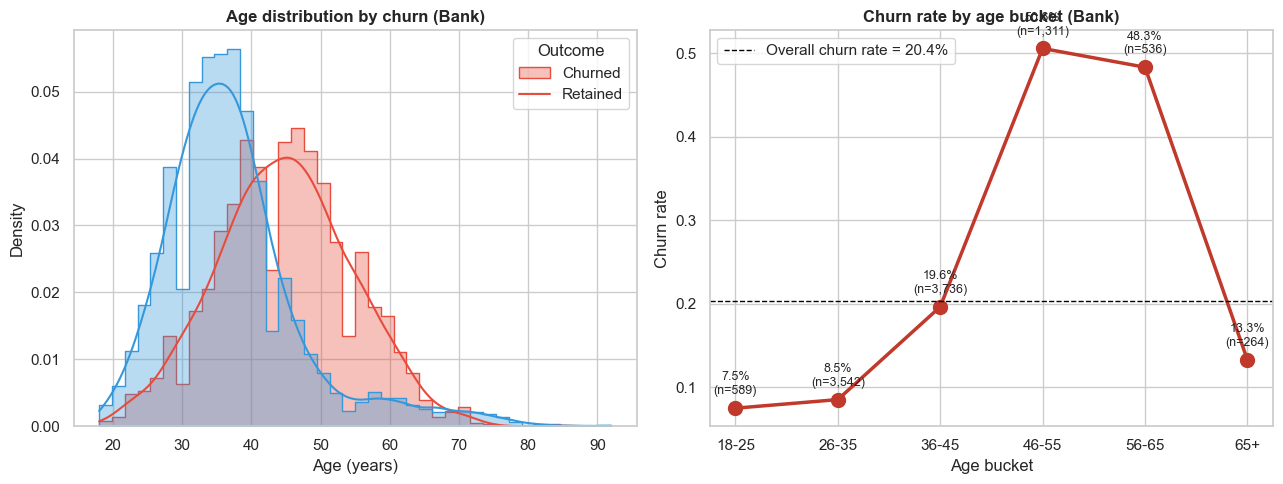

Mean age by churn status:
       mean  median   std
churn                    
0      37.4    36.0  10.1
1      44.8    45.0   9.8


In [21]:
# Age distribution by churn status (Bank)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: density histograms
sns.histplot(
    data=bank_clean, x="Age", hue="churn",
    bins=40, kde=True, palette={0: "#3498db", 1: "#e74c3c"},
    ax=axes[0], stat="density", common_norm=False, element="step", alpha=0.35,
)
axes[0].set_title("Age distribution by churn (Bank)", fontweight="bold")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Density")
axes[0].legend(["Churned", "Retained"], title="Outcome")

# Right: churn rate by age bucket
age_bins = pd.cut(bank_clean["Age"], bins=[18, 25, 35, 45, 55, 65, 100],
                  labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])
age_churn = bank_clean.groupby(age_bins, observed=True)["churn"].agg(["mean", "count"])

axes[1].plot(
    age_churn.index.astype(str), age_churn["mean"],
    marker="o", markersize=10, linewidth=2.5, color="#c0392b",
)
axes[1].axhline(
    bank_clean["churn"].mean(),
    color="black", linestyle="--", linewidth=1,
    label=f"Overall churn rate = {bank_clean['churn'].mean():.1%}",
)
axes[1].set_title("Churn rate by age bucket (Bank)", fontweight="bold")
axes[1].set_xlabel("Age bucket")
axes[1].set_ylabel("Churn rate")

for i, (rate, n) in enumerate(zip(age_churn["mean"], age_churn["count"])):
    axes[1].annotate(
        f"{rate:.1%}\n(n={n:,})",
        xy=(i, rate), xytext=(0, 10),
        textcoords="offset points", ha="center", fontsize=9,
    )

axes[1].legend()
plt.tight_layout()
plt.show()

print("Mean age by churn status:")
print(bank_clean.groupby("churn")["Age"].agg(["mean", "median", "std"]).round(1))

**Finding.** Churn risk has a striking inverted-U relationship with age. The 46-55 bucket has a 50.5% churn rate — over six times the rate of the 26-35 bucket (8.5%). Churn drops back to 13.3% in the 65+ bucket, suggesting that the highest-risk customers are middle-aged rather than elderly.

This is a much stronger signal than any single feature found in the Telco dataset. The mean age difference between churners and retainers is more than 7 years (44.8 vs 37.4). Like the price relationship in the Telco data, the structure is non-linear and will require either careful feature engineering or a non-linear model to capture fully.

### 4.8 Bank — balance, products, and activity

Beyond demographics, the bank dataset includes behavioral and account-level features. We examine three quickly: account balance, number of products held, and active-member status. These are likely correlated with churn through the same mechanism — engaged customers with multiple products and meaningful balances are harder to lose.

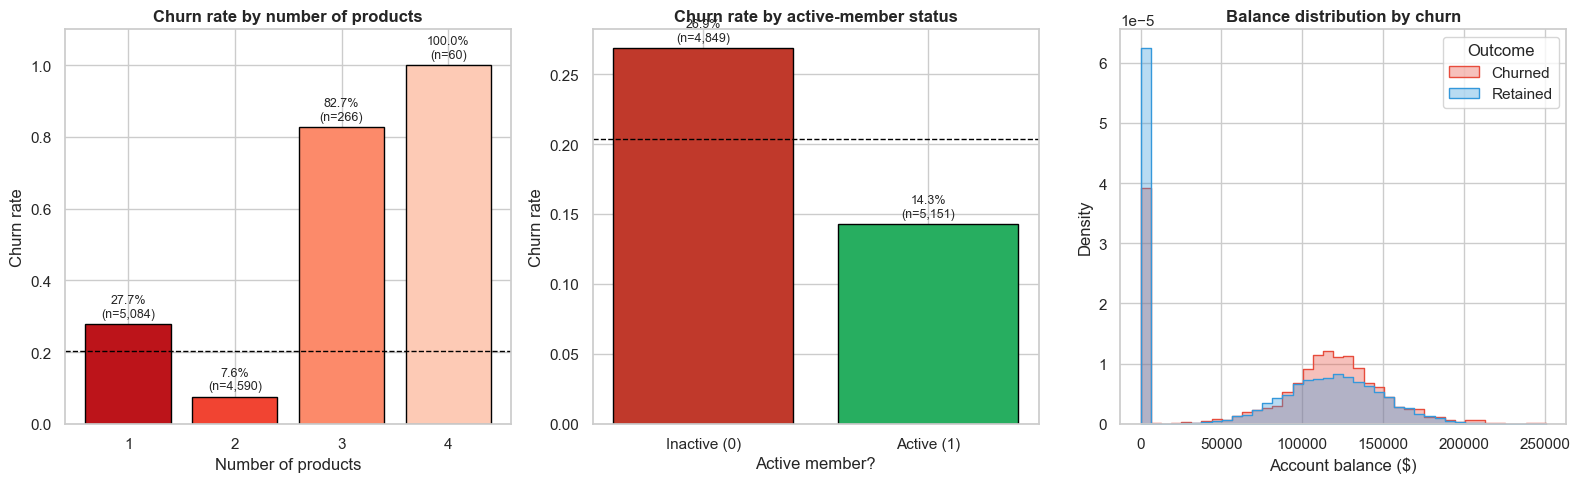

Number of products distribution and churn rate:
                rate     n
NumOfProducts             
1              0.277  5084
2              0.076  4590
3              0.827   266
4              1.000    60

Active member churn comparison:
                 rate     n
IsActiveMember             
0               0.269  4849
1               0.143  5151

Mean balance by churn status:
           mean     median
churn                     
0      72745.30   92072.68
1      91108.54  109349.29

Customers with zero balance: 3617 (36.2%)


In [22]:
# Three behavioral features vs churn (Bank)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Churn rate by NumOfProducts ---
prod_churn = (
    bank_clean.groupby("NumOfProducts")["churn"]
    .agg(["mean", "count"]).rename(columns={"mean": "rate", "count": "n"})
)
axes[0].bar(
    prod_churn.index.astype(str), prod_churn["rate"],
    color=sns.color_palette("Reds_r", n_colors=len(prod_churn)), edgecolor="black",
)
axes[0].axhline(bank_clean["churn"].mean(), color="black", linestyle="--", linewidth=1)
axes[0].set_title("Churn rate by number of products", fontweight="bold")
axes[0].set_xlabel("Number of products")
axes[0].set_ylabel("Churn rate")
for i, (rate, n) in enumerate(zip(prod_churn["rate"], prod_churn["n"])):
    axes[0].text(i, rate + 0.02, f"{rate:.1%}\n(n={n:,})", ha="center", fontsize=9)
axes[0].set_ylim(0, 1.1)

# --- 2. Churn rate by active-member status ---
active_churn = (
    bank_clean.groupby("IsActiveMember")["churn"]
    .agg(["mean", "count"]).rename(columns={"mean": "rate", "count": "n"})
)
axes[1].bar(
    ["Inactive (0)", "Active (1)"], active_churn["rate"],
    color=["#c0392b", "#27ae60"], edgecolor="black",
)
axes[1].axhline(bank_clean["churn"].mean(), color="black", linestyle="--", linewidth=1)
axes[1].set_title("Churn rate by active-member status", fontweight="bold")
axes[1].set_xlabel("Active member?")
axes[1].set_ylabel("Churn rate")
for i, (rate, n) in enumerate(zip(active_churn["rate"], active_churn["n"])):
    axes[1].text(i, rate + 0.005, f"{rate:.1%}\n(n={n:,})", ha="center", fontsize=9)

# --- 3. Balance distribution by churn ---
sns.histplot(
    data=bank_clean, x="Balance", hue="churn",
    bins=40, palette={0: "#3498db", 1: "#e74c3c"},
    ax=axes[2], stat="density", common_norm=False, element="step", alpha=0.35,
)
axes[2].set_title("Balance distribution by churn", fontweight="bold")
axes[2].set_xlabel("Account balance ($)")
axes[2].set_ylabel("Density")
axes[2].legend(["Churned", "Retained"], title="Outcome")

plt.tight_layout()
plt.show()

print("Number of products distribution and churn rate:")
print(prod_churn.round(3))
print()
print("Active member churn comparison:")
print(active_churn.round(3))
print()
print("Mean balance by churn status:")
print(bank_clean.groupby("churn")["Balance"].agg(["mean", "median"]).round(2))
print()
print(f"Customers with zero balance: {(bank_clean['Balance'] == 0).sum()} ({(bank_clean['Balance'] == 0).mean():.1%})")

**Findings.** Three distinct behavioral patterns emerge.

1. **`NumOfProducts` exhibits a dramatic U-shape.** Customers with 2 products churn least (7.6%), while customers with 1 product churn at 27.7% — and customers with 3 or 4 products churn at **82.7% and 100% respectively**. The 100% figure is over a small sample (60 customers) but is striking nonetheless. This is unlikely to represent a causal relationship in the usual sense; more plausibly, these customers are in some kind of consolidation or account-unwinding state where high product counts are a *symptom* rather than a *cause* of imminent departure. We will flag this for the modeling section: the relationship is non-linear and may need special treatment.

2. **`IsActiveMember` shows the expected effect** — inactive members churn at 26.9% vs 14.3% for active ones. A roughly 2× ratio, consistent with engagement being predictive of retention.

3. **`Balance` has a bimodal structure** — 36.2% of all customers have a balance of exactly zero (likely auxiliary or checking-only accounts), and the rest are distributed unimodally around the $100k–$130k range. Among non-zero-balance customers, churners have slightly higher balances on average ($91k vs $73k overall mean), suggesting that high-value customers may be targets of competitor poaching.

### 4.9 Bank — numeric feature correlations

We close the bank EDA with the same correlation check we performed on the Telco data, looking for multicollinearity and individual predictive strength.

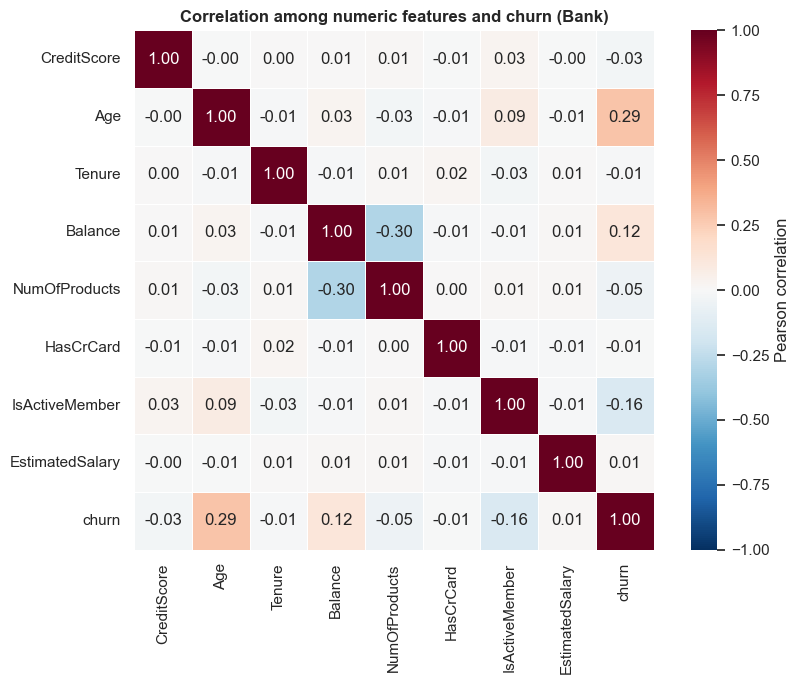

Correlations with churn (sorted by magnitude):
Age                0.285
IsActiveMember     0.156
Balance            0.119
NumOfProducts      0.048
CreditScore        0.027
Tenure             0.014
EstimatedSalary    0.012
HasCrCard          0.007
Name: churn, dtype: float64


In [23]:
# Correlation among numeric features and target (Bank)
numeric_cols_bank = [
    "CreditScore", "Age", "Tenure", "Balance",
    "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary", "churn",
]
corr_bank = bank_clean[numeric_cols_bank].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_bank, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}, ax=ax,
)
ax.set_title("Correlation among numeric features and churn (Bank)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Correlations with churn (sorted by magnitude):")
print(
    corr_bank["churn"].drop("churn").abs().sort_values(ascending=False).round(3)
)

**Finding.** Pearson correlations alone rank the bank features as: `Age` (0.29) > `IsActiveMember` (0.16) > `Balance` (0.12), with the rest below 0.05. But two observations qualify this ranking:

- **`NumOfProducts` correlates at only 0.05 despite being highly predictive** (Section 4.8 showed churn rates ranging from 7.6% to 100% across product counts). This is a textbook example of Pearson correlation failing to capture a non-monotonic relationship.
- **`Balance` ↔ `NumOfProducts` correlate at -0.30**, suggesting customers with more products have lower individual-account balances — plausibly because money is distributed across multiple accounts.

The practical implication: **linear models will be at a meaningful disadvantage on this dataset** because the strongest non-trivial signal (`NumOfProducts`) is fundamentally non-linear. We will need to either engineer non-linear features or rely on tree-based models to capture it.

## 5. EDA summary across both datasets

| Dataset | Top features by signal strength | Notable structure |
|---------|----------------------------------|-------------------|
| Telco   | `Contract`, `tenure`, `MonthlyCharges` (non-monotonic), service mix | Multicollinearity between `tenure`, `TotalCharges`, `MonthlyCharges`. Price-vs-churn is non-monotonic (suggests service-type confounding). |
| Bank    | `Age` (inverted-U), `NumOfProducts` (U-shape, extreme), `IsActiveMember`, `Geography` (Germany), `Balance` | Numerics are largely independent of each other. The strongest features have non-linear relationships with churn. |

**Cross-dataset themes.** In both domains:
- Customer commitment/engagement matters most (long contracts in Telco; active membership and middle-tenure in Bank).
- Demographics matter but in domain-specific ways (mid-life customers churn in banking; young-mid customers churn in telecom).
- The strongest relationships are often non-linear, suggesting tree-based models will be needed to capture them properly.
- A small number of features dominate the signal; many features are essentially noise.

These observations directly motivate the modeling choices in Sections 6 and 7: we will train (a) a linear baseline that handles non-linearity only after explicit feature engineering, (b) a random forest, and (c) a gradient-boosted tree model. We expect (b) and (c) to substantially outperform (a) on both datasets, with the gap being larger on the Bank dataset where the non-linear signal is more concentrated.